In [64]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import SimpleML and scikit-learn modules
from simpleml.pipeline import make_pipeline as sml_make_pipeline
import simpleml.preprocessing as sml_preprocessing
import simpleml.linear_models as sml_linear_models
import simpleml.metrics as sml_metrics
import sklearn as sk

from sklearn.datasets import make_classification

In [65]:
# Generating a synthetic classification dataset
X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

In [66]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,-1.830633,-0.095340,-0.654076,0.724051,-0.181319,0
1,0.260281,0.080151,-0.413465,-1.273314,1.482609,1
2,-1.379618,0.098744,-0.971657,-0.072798,-1.579555,1
3,-0.998061,-0.161506,1.051948,2.398537,2.120715,1
4,-0.369610,1.223565,0.621572,0.012779,-1.422353,1


In [67]:
# we can also use describe to get a statistical summary of the dataset
# although it is not necessary for the classification comparison,
# it can be useful to understand the dataset better
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,target
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.062871,0.054398,-0.037761,0.464957,-0.421863,0.504000
std,0.971978,1.293272,0.979891,1.494422,1.207009,0.500485
min,-2.940389,-3.901277,-3.019512,-3.519458,-3.610431,0.000000
25%,-0.648157,-0.919367,-0.642003,-0.574026,-1.267859,0.000000
50%,0.027732,-0.075067,-0.019340,0.561164,-0.482650,1.000000
75%,0.710774,0.989877,0.641151,1.412375,0.413152,1.000000
max,3.193108,3.873269,2.949094,4.611751,2.875353,1.000000


In [68]:
def evaluate_model(model_name, dataset, y_test, predictions):
    return {
        "model": model_name,
        "dataset": dataset,
        "accuracy": sml_metrics.accuracy_score(y_test, predictions),
        "precision": sml_metrics.precision_score(y_test, predictions),
        "recall": sml_metrics.recall_score(y_test, predictions),
        "f1_score": sml_metrics.f1_score(y_test, predictions)
    }

In [ ]:
# Splitting the dataset into training and testing sets
# I used sickit-learn's train_test_split function instead of SimpleML's
# because it allows us to stratify the split based on the target variable
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# pipleines for both SimpleML and scikit-learn
sml_pipeline = sml_make_pipeline(
    sml_preprocessing.StandardScaler(),
    sml_linear_models.SGDClassifier(random_state=42, learning_rate="invscaling" , eta0=0.01)
)

sk_pipeline = sk.pipeline.make_pipeline(
    sk.preprocessing.StandardScaler(),
    sk.linear_model.SGDClassifier(random_state=42, learning_rate="invscaling", eta0=0.01)
)
sml_model = sml_pipeline.fit(X_train, y_train)
sk_model = sk_pipeline.fit(X_train, y_train)

sml_predictions = sml_model.predict(X_test)
sk_predictions = sk_model.predict(X_test)

In [70]:
results = [
    evaluate_model("SimpleML SGDClassifier", "synthetic_classification", y_test, sml_predictions),
    evaluate_model("Sklearn SGDClassifier", "synthetic_classification", y_test, sk_predictions)
]

In [71]:
from sklearn.datasets import load_breast_cancer
breast_cancer_data = load_breast_cancer()

X , y = breast_cancer_data.data, breast_cancer_data.target

In [ ]:
# same here but for the breast cancer dataset
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sml_pipeline = sml_make_pipeline(
    sml_preprocessing.StandardScaler(),
    sml_linear_models.SGDClassifier(random_state=42, learning_rate="invscaling" , eta0=0.01)
)

sk_pipeline = sk.pipeline.make_pipeline(
    sk.preprocessing.StandardScaler(),
    sk.linear_model.SGDClassifier(random_state=42, learning_rate="invscaling", eta0=0.01)
)

sml_model = sml_pipeline.fit(X_train, y_train)
sk_model = sk_pipeline.fit(X_train, y_train)

sml_predictions = sml_model.predict(X_test)
sk_predictions = sk_model.predict(X_test)

In [73]:
results.append(evaluate_model("SimpleML SGDClassifier", "breast_cancer", y_test, sml_predictions))
results.append(evaluate_model("Sklearn SGDClassifier", "breast_cancer", y_test, sk_predictions))

In [74]:
results_df = pd.DataFrame(results)
results_df

,model,dataset,accuracy,precision,recall,f1_score
0,SimpleML SGDClassifier,synthetic_classification,0.860000,0.891304,0.820000,0.854167
1,Sklearn SGDClassifier,synthetic_classification,0.870000,0.893617,0.840000,0.865979
2,SimpleML SGDClassifier,breast_cancer,0.964912,0.972222,0.972222,0.972222
3,Sklearn SGDClassifier,breast_cancer,0.964912,0.959459,0.986111,0.972603


### It's clear that both SimpleML and scikit-learn perform similarly on both datasets, with comparable accuracy, precision, recall, and F1 scores. This suggests that SimpleML's implementation of the SGDClassifier is effective

In [75]:
from sklearn.metrics import confusion_matrix

print("SimpleML confusion matrix:")
print(confusion_matrix(y_test, sml_predictions))

print("sklearn confusion matrix:")
print(confusion_matrix(y_test, sk_predictions))

SimpleML confusion matrix:
[[40  2]
 [ 2 70]]
sklearn confusion matrix:
[[39  3]
 [ 1 71]]


### Not surprising that both gave the same confusion matrix since they have the same predictions

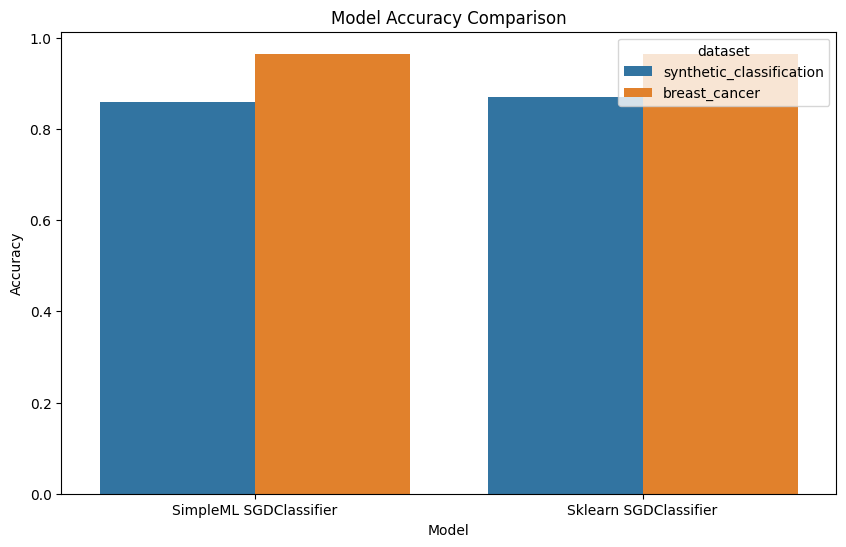

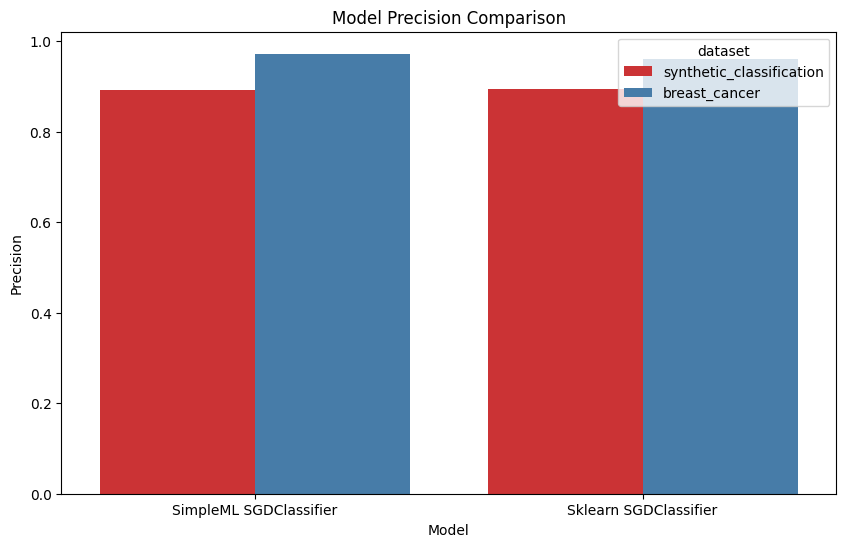

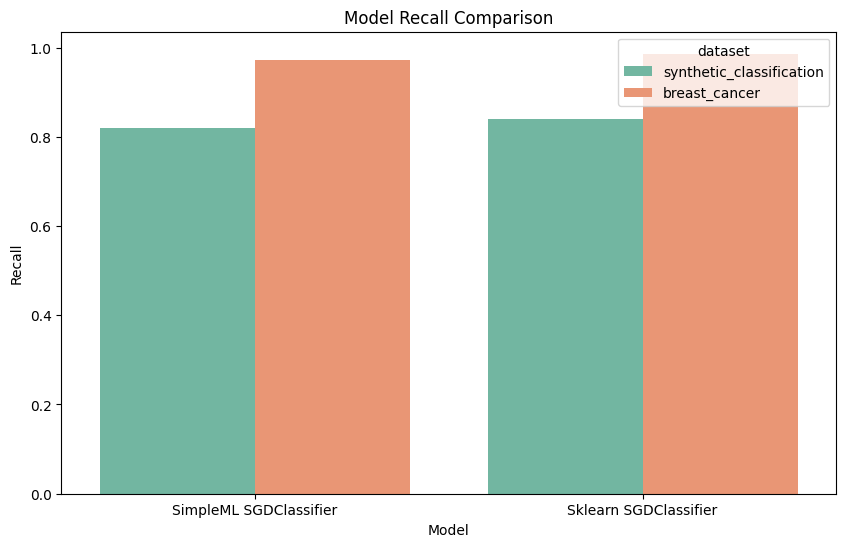

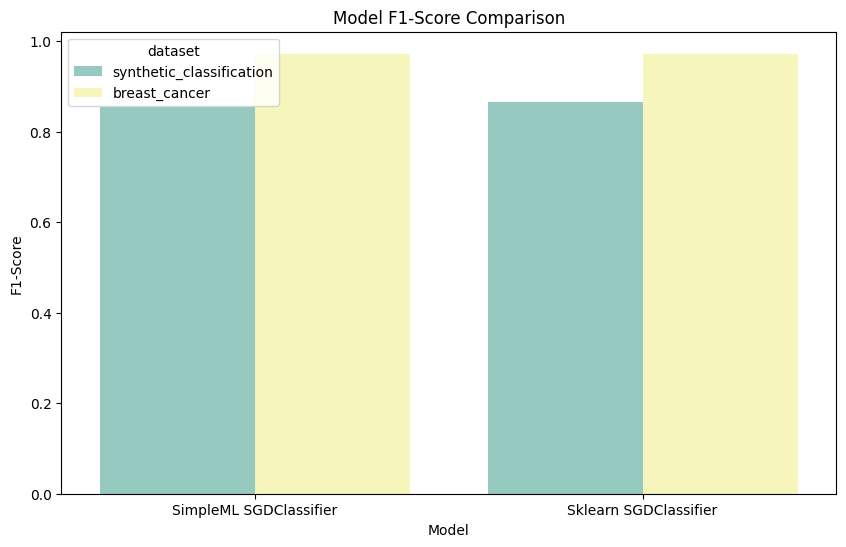

In [ ]:
# plotting accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="accuracy", hue="dataset", data=results_df)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

# plotting precision comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="precision", hue="dataset", data=results_df, palette="Set1")
plt.title("Model Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.show()

# plotting recall comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="recall", hue="dataset", data=results_df, palette="Set2")
plt.title("Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.show()

# plotting F1-score comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="f1_score", hue="dataset", data=results_df, palette="Set3")
plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.show()